# Skills Trend: How are in-demand skills trending for Data Analysts?

## Import Libraries and Data

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Loading Dataset
df = pd.read_csv(r'C:\Users\ARJUN\Python_projects\Python_Course\data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

## Filter for US Data Analysts

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

## Extract the month number from the job posted date and expode the job skills

In [3]:
df_DA_US['job_posted_month_number'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_exploded = df_DA_US.explode('job_skills')

## Monthly skill count pivot

In [4]:
df_DA_US_pivot = df_DA_US_exploded.pivot_table(index = 'job_posted_month_number', columns = 'job_skills', aggfunc = 'size', fill_value = 0) # .fillna(0)
df_DA_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month_number,,,,,,,,,,,,,,,,,,,,,
1,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
2,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
3,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
4,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
5,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
6,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
7,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
8,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
9,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


## Sort skills based on the descending order of their total values

In [5]:
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending = False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

## Convert month numbers to month names and set them as the index

In [6]:
df_DA_US_pivot.reset_index(inplace = True)
df_DA_US_pivot['job_posted_month'] = pd.to_datetime(df_DA_US_pivot['job_posted_month_number'], format = '%m').dt.strftime('%b')
df_DA_US_pivot.drop(labels = ['job_posted_month_number'], axis = 1, inplace = True)
df_DA_US_pivot.set_index('job_posted_month', inplace = True)
df_DA_US_pivot

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,google chat,openstack,theano,asp.net core,qt,couchdb,capacitor,codecommit,chainer,msaccess
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,0,0,0,0,0,0,1,1,0,0
Feb,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
Mar,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,1,0,0,0,0,0,0,0,0,0
Apr,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,1,0,0,0,0
May,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,0,0,0,0,1
Jun,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,1,0,0,1,0,0,0,0,0
Jul,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
Aug,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
Sep,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


## Plot Skill Counts

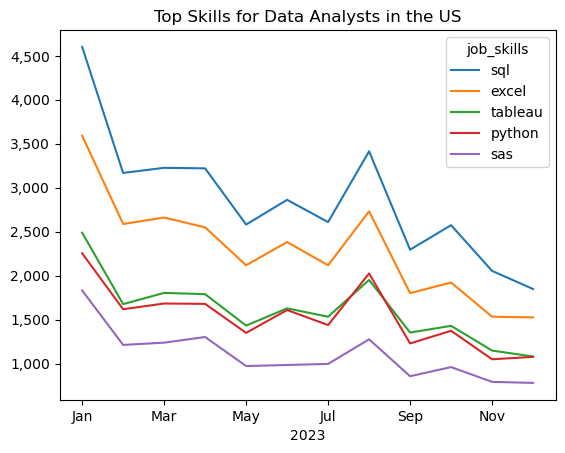

In [7]:
df_DA_US_pivot.iloc[:,:5].plot(kind = 'line')
plt.title('Top Skills for Data Analysts in the US')
plt.xlabel('2023')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

## Calculate Percentage of Total Jobs

In [8]:
# Monthly job posting totals
DA_US_totals = df_DA_US.groupby('job_posted_month_number').size().to_frame(name = 'job_cnt')
DA_US_totals.reset_index(inplace = True)
DA_US_totals['job_posted_month'] = pd.to_datetime(DA_US_totals['job_posted_month_number'], format = '%m').dt.strftime('%b')
DA_US_totals.drop(labels = ['job_posted_month_number'], axis = 1, inplace = True)
DA_US_totals.set_index('job_posted_month', inplace = True)
DA_US_totals

,job_cnt
job_posted_month,
Jan,8494
Feb,6124
Mar,6218
Apr,6049
May,4993
Jun,5683
Jul,5201
Aug,6634
Sep,4639


In [9]:
# divide first 12 rows of df_DA_US_pivot by DA_US_totals
df_DA_US_perc = df_DA_US_pivot.div(DA_US_totals['job_cnt'] / 100, axis = 0)
df_DA_US_perc
# Note: for element-wise operations like '.div', axis = 0 aligns on the row index, and axis = 1 aligns on the column index

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,google chat,openstack,theano,asp.net core,qt,couchdb,capacitor,codecommit,chainer,msaccess
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,54.167648,42.288674,29.291264,26.536379,21.568166,17.812574,15.740523,11.396280,11.443372,8.453026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011773,0.011773,0.000000,0.000000
Feb,51.730895,42.243632,27.367734,26.420640,19.790986,17.064010,18.321359,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,51.881634,42.795111,29.012544,27.066581,19.909939,18.349952,16.950788,11.836603,10.759087,6.722419,...,0.016082,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,53.231939,42.139197,29.575136,27.756654,21.524219,17.159861,17.473963,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.016532,0.000000,0.000000,0.000000,0.000000
May,51.692369,42.419387,28.680152,27.017825,19.467254,17.364310,17.224114,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020028
Jun,50.360725,41.914482,28.646841,28.312511,17.314799,17.895478,17.402780,12.686961,10.980116,7.284885,...,0.000000,0.017596,0.000000,0.000000,0.017596,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,51.462165,41.166717,29.409105,30.524570,19.234248,19.158879,18.209225,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,49.471869,38.823022,29.165768,26.492779,18.452253,16.081052,17.676223,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Plot Monthly Skill Demand

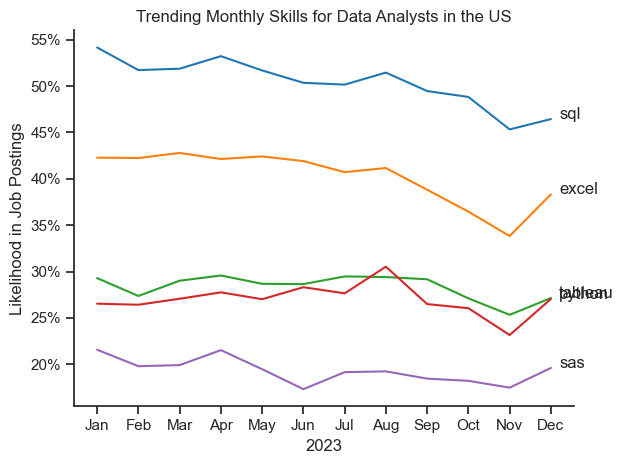

In [10]:
df_plot = df_DA_US_perc.iloc[:,:5]

sns.set_theme(style = 'ticks')

sns.lineplot(data = df_plot, palette = 'tab10', dashes = False)
sns.despine()
plt.title('Trending Monthly Skills for Data Analysts in the US')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Postings')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
plt.legend().set_visible(False)

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1,i], df_plot.columns[i]) # fetching the last value of each column

plt.tight_layout()
plt.show()